In [29]:
import sys
import os

# The notebook is assumed to be at the root level of the repository
# with 'groups' and 'tournament.py' as sibling directories/files.
# Therefore, no modification to sys.path or os.chdir is needed.
print(f"Current working directory: {os.getcwd()}")
print(f"'tournament.py' and 'groups' are expected to be in this directory or subdirectories of it.")

import os
import sys
import importlib.util
from pathlib import Path
import time
from datetime import datetime, timedelta
import pandas as pd
import matplotlib.pyplot as plt

# The notebook is assumed to be at the root level of the repository
# with 'groups' and 'tournament.py' as sibling directories/files.
# No project_root definition or sys.path modification is needed here.

import tournament # Import the tournament module from the current directory

# Ensure the 'versus' directory exists within the current working directory
Path("versus").mkdir(parents=True, exist_ok=True)

# Función para cargar dinámicamente una política desde un archivo
def load_policy_class(filepath):
    """Carga una clase Policy desde un un path relativo."""
    # Use a unique module name for each import to avoid conflicts if paths are similar
    module_name = Path(filepath).stem # Use filename as module name
    spec = importlib.util.spec_from_file_location(module_name, filepath)
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module # Add to sys.modules to prevent re-import issues if loaded multiple times
    spec.loader.exec_module(module)
    # Buscar la clase Policy
    for name in dir(module):
        obj = getattr(module, name)
        if isinstance(obj, type) and "Policy" in name and name != "Policy":
            return obj
    raise ImportError(f"No Policy class found in {filepath}")

Current working directory: c:\Users\storr\OneDrive - Universidad de la Sabana\6to Semestre\fund ia\tournament\tournament
'tournament.py' and 'groups' are expected to be in this directory or subdirectories of it.


## **NOTA**
Referirse a README.md para verificar la estructura de carpetas en caso de ejecutar este notebook. Además la probabilidad de ser rojo o amarillo está definida en 50/50 así los resultados son independientes del color del agente.

# **Estadísticas de V1,2,3 vs Agente Aleatorio**
Se observa que las tres versiones del agente consiguen un win rate del 100%

In [28]:


# --- Experiment Configuration ---
main_agents_to_compare = [
    ("groups/tbopiv3/policy.py", "tbopiv3"),
    ("groups/tbopiv2/policy.py", "tbopiv2"),
    ("groups/tbopiv1/policy.py", "tbopiv1") # Added tbopiv1
]
random_agent_path = "groups/random_agent/policy.py"
random_agent_name = "random_agent"

trials_values = list(range(10, 51, 10)) # Trials from 10 to 50, step 10
num_partidas_per_setting = 10 # 10 games per agent/trials combination

# Load the random agent policy class once
RandomAgentClass = load_policy_class(random_agent_path)

# Store results for DataFrame and plotting
comparison_results = []

print("Iniciando comparación de agentes con diferentes números de trials...")

for main_agent_path, main_agent_name in main_agents_to_compare:
    print(f"\nComparando {main_agent_name} contra {random_agent_name}...")
    MainAgentClass = load_policy_class(main_agent_path)

    for current_trials in trials_values:
        print(f"  Ejecutando con trials={current_trials} ({num_partidas_per_setting} partidas)... ", end='')
        wins = 0
        losses = 0
        draws = 0

        for _ in range(num_partidas_per_setting):
            # Instantiate agents, passing 'n_trials' to MCTS-like agents
            try:
                agente_principal_instance = MainAgentClass(n_trials=current_trials)
            except TypeError: # Fallback if MainAgentClass doesn't accept 'n_trials' argument (e.g., if it's not an MCTS agent)
                print(f"\n    Warning: {main_agent_name} Policy does not accept 'n_trials' argument. Instantiating without.")
                agente_principal_instance = MainAgentClass()

            # Random agent typically doesn't use 'n_trials'
            agente_rival_instance = RandomAgentClass()

            participant_a = (main_agent_name, lambda ap=agente_principal_instance: ap)
            participant_b = (random_agent_name, lambda ar=agente_rival_instance: ar)

            # Play 1 game, with a time limit of 0.5 seconds per move
            winner = tournament.play(participant_a, participant_b, 1, 0.5) # Call tournament.play

            if winner[0] == main_agent_name:
                wins += 1
            elif winner[0] == random_agent_name:
                losses += 1
            else:
                draws += 1

        total_games = wins + losses + draws
        win_rate = (wins / total_games * 100) if total_games > 0 else 0

        comparison_results.append({
            'agent': main_agent_name,
            'trials': current_trials,
            'wins': wins,
            'losses': losses,
            'draws': draws,
            'total_games': total_games,
            'win_rate': round(win_rate, 2)
        })
        print(f"Resultados: Victorias: {wins}, Derrotas: {losses}, Empates: {draws}, Tasa de victoria: {win_rate:.2f}%")

# Create DataFrame from results
df_comparison = pd.DataFrame(comparison_results)

print("\n" + "="*70)
print("DataFrame de Resultados de Comparación")
print("="*70)
print(df_comparison)

# --- Plotting Results ---
print("\nGenerando gráficas de rendimiento...")
plt.figure(figsize=(12, 7))

for agent_name in df_comparison['agent'].unique():
    agent_data = df_comparison[df_comparison['agent'] == agent_name]
    plt.plot(agent_data['trials'], agent_data['win_rate'], marker='o', label=f'{agent_name} vs {random_agent_name}')

plt.title('Rendimiento de Agentes vs Agente Aleatorio por Número de Trials')
plt.xlabel('Número de Trials')
plt.ylabel('Tasa de Victoria (%)')
plt.xticks(trials_values) # Show all x-ticks for this smaller range
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

print("\nComparación completada y gráficas mostradas.")

Iniciando comparación de agentes con diferentes números de trials...

Comparando tbopiv3 contra random_agent...
  Ejecutando con trials=10 (10 partidas)... 

NameError: name 'tournament' is not defined

# **Estadísticas de V1,2,3 compitiendo entre ellos**
El agente que obtuvo mayor win rate fue la v2, esto se atribuye a que probablemente los q-values aprendidos previamente por la v3 representan un porcentaje muy bajo de los casos possibles haciendo que en ocasiones sus decisiones se guíen de forma casi aleatoria. Además el cesgo hacia las columnas centrales está implicita en la lógica de aprendizaje y por tener pocos q-values ese cesgo se pierde en la práctica.


Iniciando comparación directa entre agentes variando n_trials de 0 a 150...

Comparando tbopiv3 vs tbopiv2 con n_trials=0...
  tbopiv3 (Player 1) vs tbopiv2 (Player 2) - 10 games...
  tbopiv2 (Player 1) vs tbopiv3 (Player 2) - 10 games...
  Resultados para tbopiv3 vs tbopiv2 (n_trials=0): tbopiv3 Victorias: 10, tbopiv2 Victorias: 10, Empates: 0, Tasa de victoria tbopiv3: 50.00%

Comparando tbopiv3 vs tbopiv2 con n_trials=10...
  tbopiv3 (Player 1) vs tbopiv2 (Player 2) - 10 games...
  tbopiv2 (Player 1) vs tbopiv3 (Player 2) - 10 games...
  Resultados para tbopiv3 vs tbopiv2 (n_trials=10): tbopiv3 Victorias: 7, tbopiv2 Victorias: 13, Empates: 0, Tasa de victoria tbopiv3: 35.00%

Comparando tbopiv3 vs tbopiv2 con n_trials=20...
  tbopiv3 (Player 1) vs tbopiv2 (Player 2) - 10 games...
  tbopiv2 (Player 1) vs tbopiv3 (Player 2) - 10 games...
  Resultados para tbopiv3 vs tbopiv2 (n_trials=20): tbopiv3 Victorias: 12, tbopiv2 Victorias: 8, Empates: 0, Tasa de victoria tbopiv3: 60.00%

Compa

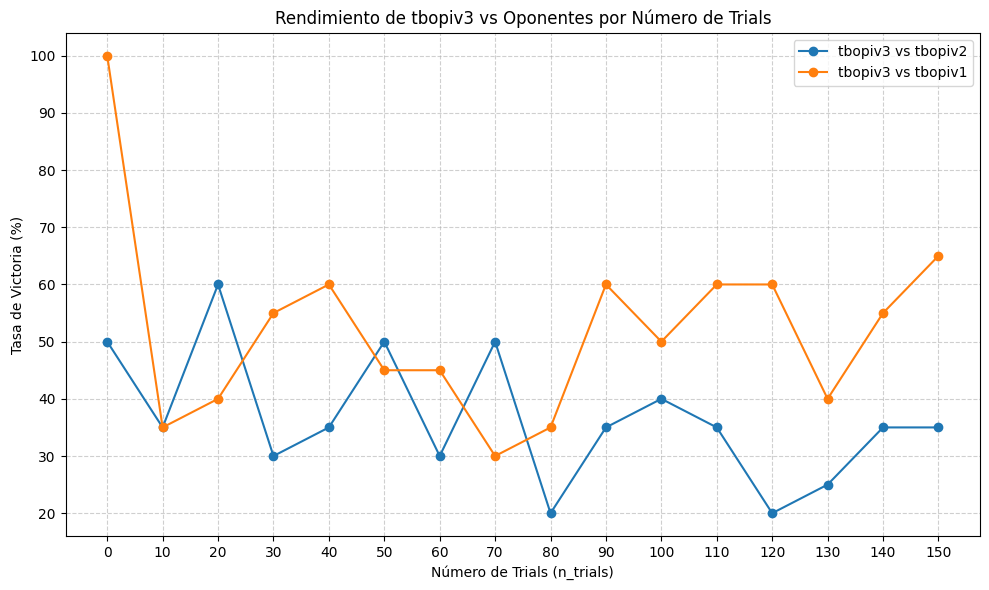

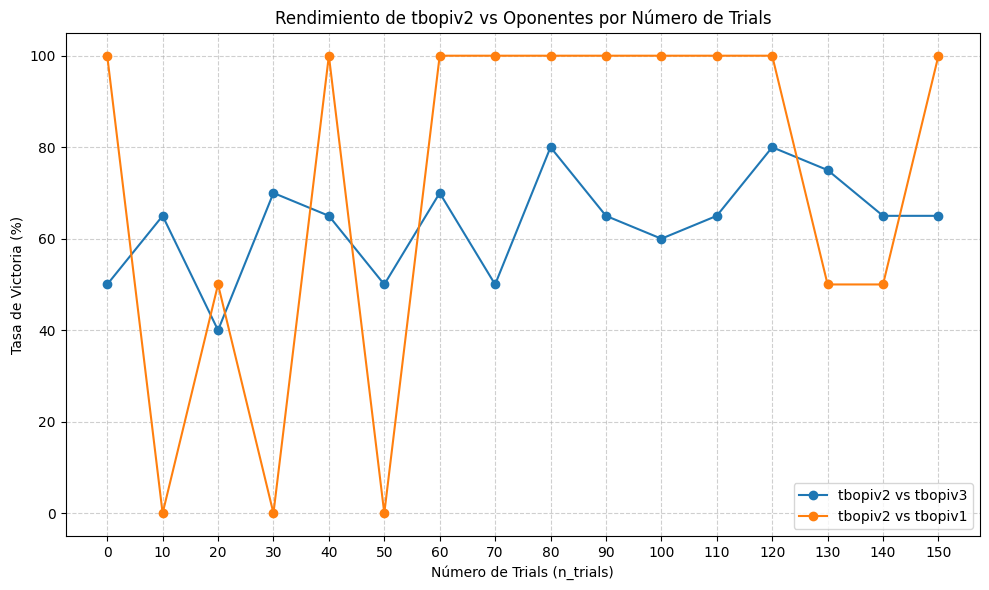

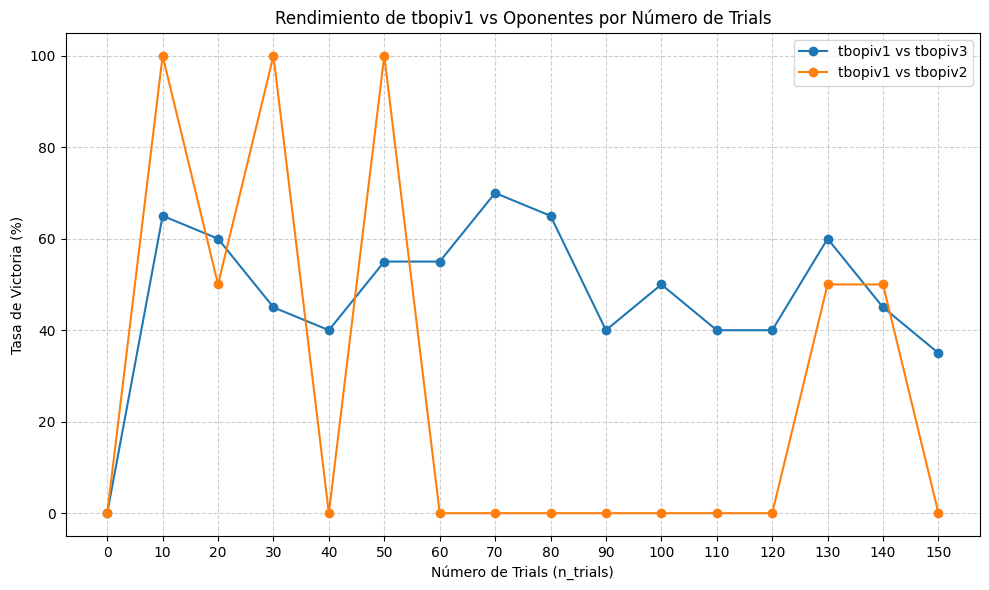


Comparación y gráficas de rendimiento por agente completadas.

Análisis del Ganador General
Tasa de victoria promedio de cada agente en todas las comparaciones:
main_agent
tbopiv2    67.65625
tbopiv3    44.37500
tbopiv1    37.96875
Name: win_rate, dtype: float64

El agente con la mejor tasa de victoria total es: tbopiv2 con un promedio de 67.66%


In [31]:
import pandas as pd
import itertools
import os
import matplotlib.pyplot as plt # Import for plotting

# --- Experiment Configuration for direct comparison ---
agents_to_compare_directly = [
    ("groups/tbopiv3/policy.py", "tbopiv3"),
    ("groups/tbopiv2/policy.py", "tbopiv2"),
    ("groups/tbopiv1/policy.py", "tbopiv1")
]

trials_values_direct_comparison = list(range(0, 151, 10)) # Trials from 0 to 150, step 10 (covering 25 to 75 as requested earlier)
num_games_per_matchup = 10 # Number of games for agent A vs B, and then B vs A

direct_comparison_results_detailed = [] # Store results in a more plot-friendly format
agent_classes = {}

print(f"\nIniciando comparación directa entre agentes variando n_trials de {trials_values_direct_comparison[0]} a {trials_values_direct_comparison[-1]}...")

# Load all agent classes once
for agent_path, agent_name in agents_to_compare_directly:
    agent_classes[agent_name] = load_policy_class(agent_path)

# Generate all unique pairs of agents for comparison
agent_pairs = list(itertools.combinations(agents_to_compare_directly, 2))

for (path_a, name_a), (path_b, name_b) in agent_pairs:
    for current_trials_dc in trials_values_direct_comparison:
        print(f"\nComparando {name_a} vs {name_b} con n_trials={current_trials_dc}...")

        # Initialize results for this specific matchup and trials setting
        wins_a = 0
        wins_b = 0
        draws = 0

        # Matchup 1: Agent A as participant_a, Agent B as participant_b
        print(f"  {name_a} (Player 1) vs {name_b} (Player 2) - {num_games_per_matchup} games...")
        for _ in range(num_games_per_matchup):
            try:
                agent_a_instance = agent_classes[name_a](n_trials=current_trials_dc)
            except TypeError:
                agent_a_instance = agent_classes[name_a]()

            try:
                agent_b_instance = agent_classes[name_b](n_trials=current_trials_dc)
            except TypeError:
                agent_b_instance = agent_classes[name_b]()

            participant_a = (name_a, lambda ap=agent_a_instance: ap)
            participant_b = (name_b, lambda bp=agent_b_instance: bp)

            winner = tournament.play(participant_a, participant_b, 1, 0.5)

            if winner[0] == name_a:
                wins_a += 1
            elif winner[0] == name_b:
                wins_b += 1
            else:
                draws += 1

        # Matchup 2: Agent B as participant_a, Agent A as participant_b (to mitigate first player bias)
        print(f"  {name_b} (Player 1) vs {name_a} (Player 2) - {num_games_per_matchup} games...")
        for _ in range(num_games_per_matchup):
            try:
                agent_b_instance = agent_classes[name_b](n_trials=current_trials_dc)
            except TypeError:
                agent_b_instance = agent_classes[name_b]()

            try:
                agent_a_instance = agent_classes[name_a](n_trials=current_trials_dc)
            except TypeError:
                agent_a_instance = agent_classes[name_a]()

            participant_a = (name_b, lambda bp=agent_b_instance: bp)
            participant_b = (name_a, lambda ap=agent_a_instance: ap)

            winner = tournament.play(participant_a, participant_b, 1, 0.5)

            if winner[0] == name_b:
                wins_b += 1
            elif winner[0] == name_a:
                wins_a += 1
            else:
                draws += 1

        total_games_in_matchup = (num_games_per_matchup * 2)
        win_rate_a = (wins_a / total_games_in_matchup * 100) if total_games_in_matchup > 0 else 0
        win_rate_b = (wins_b / total_games_in_matchup * 100) if total_games_in_matchup > 0 else 0

        # Store results for Agent A's perspective
        direct_comparison_results_detailed.append({
            'main_agent': name_a,
            'opponent': name_b,
            'n_trials': current_trials_dc,
            'wins': wins_a,
            'losses': wins_b + draws,
            'draws': draws,
            'total_games': total_games_in_matchup,
            'win_rate': round(win_rate_a, 2)
        })
        # Store results for Agent B's perspective
        direct_comparison_results_detailed.append({
            'main_agent': name_b,
            'opponent': name_a,
            'n_trials': current_trials_dc,
            'wins': wins_b,
            'losses': wins_a + draws,
            'draws': draws,
            'total_games': total_games_in_matchup,
            'win_rate': round(win_rate_b, 2)
        })
        print(f"  Resultados para {name_a} vs {name_b} (n_trials={current_trials_dc}): {name_a} Victorias: {wins_a}, {name_b} Victorias: {wins_b}, Empates: {draws}, Tasa de victoria {name_a}: {win_rate_a:.2f}%")

df_direct_comparison_detailed = pd.DataFrame(direct_comparison_results_detailed)

print("\n" + "="*70)
print("DataFrame de Resultados de Comparación Directa Detallada entre Agentes")
print("="*70)
print(df_direct_comparison_detailed)

# --- Plotting Results for each agent ---
print("\nGenerando gráficas de rendimiento para cada agente...")

unique_agents = [agent_tuple[1] for agent_tuple in agents_to_compare_directly]

for agent_to_plot in unique_agents:
    plt.figure(figsize=(10, 6))
    agent_data = df_direct_comparison_detailed[df_direct_comparison_detailed['main_agent'] == agent_to_plot]

    # Get opponents for the current agent
    opponents = agent_data['opponent'].unique()

    for opponent in opponents:
        plot_data = agent_data[agent_data['opponent'] == opponent]
        plt.plot(plot_data['n_trials'], plot_data['win_rate'], marker='o', label=f'{agent_to_plot} vs {opponent}')

    plt.title(f'Rendimiento de {agent_to_plot} vs Oponentes por Número de Trials')
    plt.xlabel('Número de Trials (n_trials)')
    plt.ylabel('Tasa de Victoria (%)')
    plt.xticks(trials_values_direct_comparison)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

print("\nComparación y gráficas de rendimiento por agente completadas.")

# --- Final overall win rate analysis ---
print("\n" + "="*70)
print("Análisis del Ganador General")
print("="*70)

# Calculate the average win rate for each agent across all matchups and trials settings
overall_win_rates = df_direct_comparison_detailed.groupby('main_agent')['win_rate'].mean().sort_values(ascending=False)

print("Tasa de victoria promedio de cada agente en todas las comparaciones:")
print(overall_win_rates)

if not overall_win_rates.empty:
    best_agent = overall_win_rates.index[0]
    best_win_rate = overall_win_rates.values[0]
    print(f"\nEl agente con la mejor tasa de victoria total es: {best_agent} con un promedio de {best_win_rate:.2f}%")
else:
    print("No hay datos disponibles para calcular la tasa de victoria total.")

# **Estadísticas de V1,2,3 contra si mismos**


Iniciando comparación de agentes contra sí mismos, variando n_trials de 0 a 100...

Comparando tbopiv3 vs tbopiv3 con n_trials=0...
  tbopiv3 (Player 1) vs tbopiv3 (Player 2) - 10 games...
  Resultados para tbopiv3 vs tbopiv3 (n_trials=0): Victorias: 10, Derrotas: 0, Empates: 0, Tasa de victoria: 100.00%

Comparando tbopiv3 vs tbopiv3 con n_trials=10...
  tbopiv3 (Player 1) vs tbopiv3 (Player 2) - 10 games...
  Resultados para tbopiv3 vs tbopiv3 (n_trials=10): Victorias: 10, Derrotas: 0, Empates: 0, Tasa de victoria: 100.00%

Comparando tbopiv3 vs tbopiv3 con n_trials=20...
  tbopiv3 (Player 1) vs tbopiv3 (Player 2) - 10 games...
  Resultados para tbopiv3 vs tbopiv3 (n_trials=20): Victorias: 10, Derrotas: 0, Empates: 0, Tasa de victoria: 100.00%

Comparando tbopiv3 vs tbopiv3 con n_trials=30...
  tbopiv3 (Player 1) vs tbopiv3 (Player 2) - 10 games...
  Resultados para tbopiv3 vs tbopiv3 (n_trials=30): Victorias: 10, Derrotas: 0, Empates: 0, Tasa de victoria: 100.00%

Comparando tbopiv

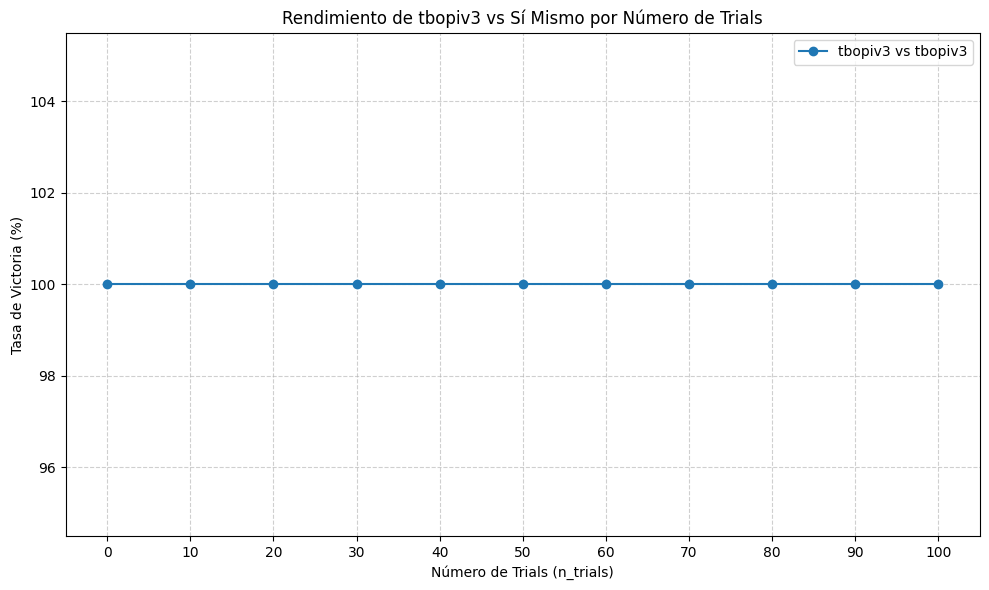

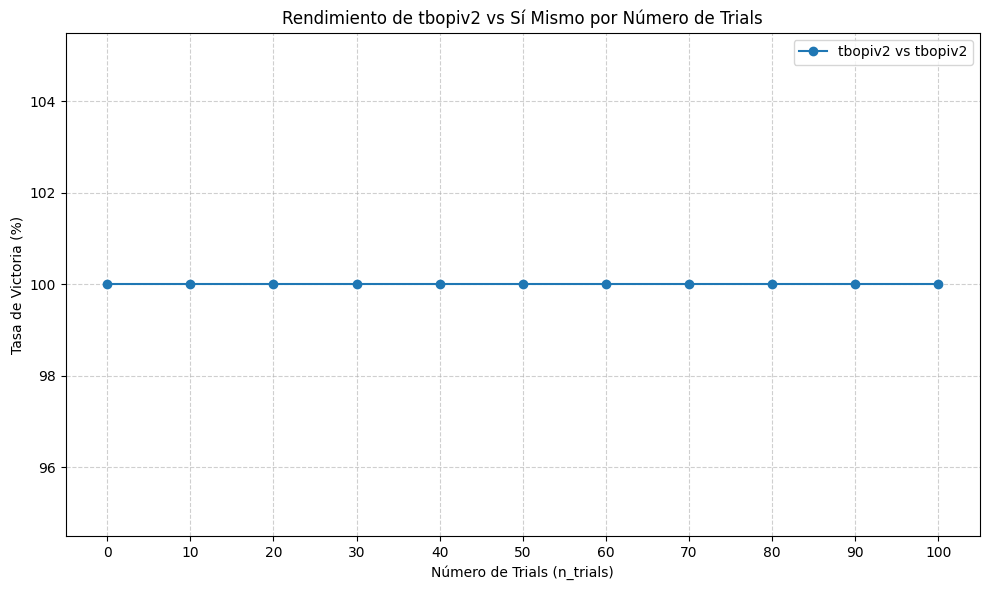

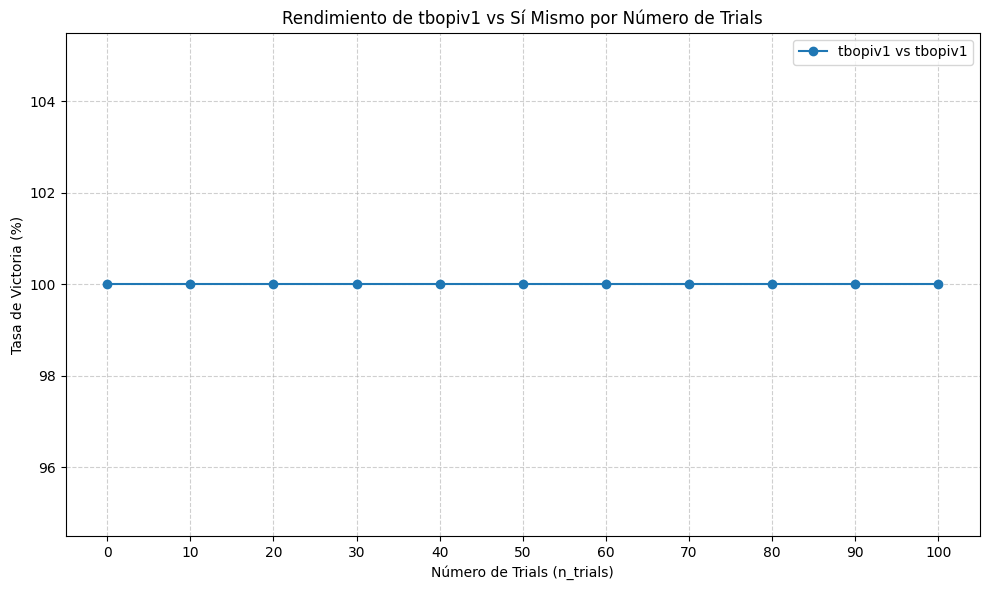


Comparación y gráficas de rendimiento por agente completadas.

Análisis del Ganador General (Self-Play)
Tasa de victoria promedio de cada agente contra sí mismo:
main_agent
tbopiv1    100.0
tbopiv2    100.0
tbopiv3    100.0
Name: win_rate, dtype: float64

El agente con la mejor tasa de victoria promedio en auto-comparación es: tbopiv1 con un promedio de 100.00%


In [35]:
import pandas as pd
import itertools
import os
import matplotlib.pyplot as plt

# --- Experiment Configuration for direct comparison ---
agents_to_compare_directly = [
    ("groups/tbopiv3/policy.py", "tbopiv3"),
    ("groups/tbopiv2/policy.py", "tbopiv2"),
    ("groups/tbopiv1/policy.py", "tbopiv1")
]

trials_values_direct_comparison = list(range(0, 101, 10)) # Trials from 0 to 100, step 10
num_games_per_matchup = 10 # Number of games for agent A vs B, and then B vs A

direct_comparison_results_detailed = [] # Store results in a more plot-friendly format
agent_classes = {}

print(f"\nIniciando comparación de agentes contra sí mismos, variando n_trials de {trials_values_direct_comparison[0]} a {trials_values_direct_comparison[-1]}...")

# Load all agent classes once
for agent_path, agent_name in agents_to_compare_directly:
    agent_classes[agent_name] = load_policy_class(agent_path)

# Generate pairs for self-comparison only
agent_self_pairs = []
for agent_info in agents_to_compare_directly:
    agent_self_pairs.append((agent_info, agent_info))

for (path_a, name_a), (path_b, name_b) in agent_self_pairs:
    for current_trials_dc in trials_values_direct_comparison:
        print(f"\nComparando {name_a} vs {name_b} con n_trials={current_trials_dc}...")

        # Initialize results for this specific matchup and trials setting
        wins_a = 0
        wins_b = 0
        draws = 0

        # Matchup 1: Agent A as participant_a, Agent B as participant_b
        print(f"  {name_a} (Player 1) vs {name_b} (Player 2) - {num_games_per_matchup} games...")
        for _ in range(num_games_per_matchup):
            try:
                agent_a_instance = agent_classes[name_a](n_trials=current_trials_dc)
            except TypeError:
                agent_a_instance = agent_classes[name_a]()

            try:
                agent_b_instance = agent_classes[name_b](n_trials=current_trials_dc)
            except TypeError:
                agent_b_instance = agent_classes[name_b]()

            participant_a = (name_a, lambda ap=agent_a_instance: ap)
            participant_b = (name_b, lambda bp=agent_b_instance: bp)

            winner = tournament.play(participant_a, participant_b, 1, 0.5)

            if winner[0] == name_a:
                wins_a += 1
            elif winner[0] == name_b:
                wins_b += 1
            else:
                draws += 1

        # For self-comparison, we only run one set of games (A vs A), so total games is just num_games_per_matchup
        total_games_in_matchup = num_games_per_matchup
        win_rate_a = (wins_a / total_games_in_matchup * 100) if total_games_in_matchup > 0 else 0

        # When comparing against self, win_rate_b is conceptually irrelevant or identical to win_rate_a
        # We'll just report win_rate_a

        # Store results for Agent A's perspective (main_agent vs itself)
        direct_comparison_results_detailed.append({
            'main_agent': name_a,
            'opponent': name_b, # This will be the same as main_agent for self-comparison
            'n_trials': current_trials_dc,
            'wins': wins_a,
            'losses': wins_b, # For self-play, losses here mean the agent didn't win
            'draws': draws,
            'total_games': total_games_in_matchup,
            'win_rate': round(win_rate_a, 2)
        })

        print(f"  Resultados para {name_a} vs {name_b} (n_trials={current_trials_dc}): Victorias: {wins_a}, Derrotas: {wins_b}, Empates: {draws}, Tasa de victoria: {win_rate_a:.2f}%")

df_direct_comparison_detailed = pd.DataFrame(direct_comparison_results_detailed)

print("\n" + "="*70)
print("DataFrame de Resultados de Comparación Directa Detallada (Self-Play)")
print("="*70)
print(df_direct_comparison_detailed)

# --- Plotting Results for each agent ---
print("\nGenerando gráficas de rendimiento para cada agente (Self-Play)...")

unique_agents = [agent_tuple[1] for agent_tuple in agents_to_compare_directly]

for agent_to_plot in unique_agents:
    plt.figure(figsize=(10, 6))
    agent_data = df_direct_comparison_detailed[df_direct_comparison_detailed['main_agent'] == agent_to_plot]

    # For self-comparison, the opponent is always the agent itself
    opponent_name = agent_to_plot
    plot_data = agent_data[agent_data['opponent'] == opponent_name]
    plt.plot(plot_data['n_trials'], plot_data['win_rate'], marker='o', label=f'{agent_to_plot} vs {opponent_name}')

    plt.title(f'Rendimiento de {agent_to_plot} vs Sí Mismo por Número de Trials')
    plt.xlabel('Número de Trials (n_trials)')
    plt.ylabel('Tasa de Victoria (%)')
    plt.xticks(trials_values_direct_comparison)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

print("\nComparación y gráficas de rendimiento por agente completadas.")

# --- Final overall win rate analysis (Self-Play) ---
print("\n" + "="*70)
print("Análisis del Ganador General (Self-Play)")
print("="*70)

# Calculate the average win rate for each agent across all self-play trials
overall_win_rates_self_play = df_direct_comparison_detailed.groupby('main_agent')['win_rate'].mean().sort_values(ascending=False)

print("Tasa de victoria promedio de cada agente contra sí mismo:")
print(overall_win_rates_self_play)

if not overall_win_rates_self_play.empty:
    best_agent_self_play = overall_win_rates_self_play.index[0]
    best_win_rate_self_play = overall_win_rates_self_play.values[0]
    print(f"\nEl agente con la mejor tasa de victoria promedio en auto-comparación es: {best_agent_self_play} con un promedio de {best_win_rate_self_play:.2f}%")
else:
    print("No hay datos disponibles para calcular la tasa de victoria total en auto-comparación.")

# **Comportamiento de tiempo de computación según n de trials**

In [ ]:
import time
import pandas as pd
import itertools
import os
import matplotlib.pyplot as plt
import importlib.util
from pathlib import Path

# Assuming `load_policy_class` is defined in a previous cell and `tournament` is imported.
# No project_root definition or sys.path modification is needed here.

# Helper class to wrap the policy's act method and measure time
class TimeMeasuringPolicyWrapper:
    def __init__(self, original_policy_class, n_trials_val=None):
        self.original_policy_class = original_policy_class
        self.n_trials_val = n_trials_val
        self.total_act_time = 0.0
        self.act_call_count = 0
        self.current_instance = None

    # This method is called by tournament.play at the start of each game to get the agent instance
    def __call__(self):
        # Instantiate the original policy with n_trials, handling TypeError if not applicable
        try:
            self.current_instance = self.original_policy_class(n_trials=self.n_trials_val)
        except TypeError:
            self.current_instance = self.original_policy_class()

        # Override the act method of this specific instance to measure time
        original_act = self.current_instance.act
        def wrapped_act(board):
            start_time = time.time()
            action = original_act(board)
            end_time = time.time()
            self.total_act_time += (end_time - start_time)
            self.act_call_count += 1
            return action
        self.current_instance.act = wrapped_act
        return self.current_instance

# --- Experiment Configuration for time measurement (Self-Play) ---
agents_to_compare_for_time = [
    ("groups/tbopiv3/policy.py", "tbopiv3"),
    ("groups/tbopiv2/policy.py", "tbopiv2"),
    ("groups/tbopiv1/policy.py", "tbopiv1")
]

trials_values_for_time = list(range(0, 101, 10)) # Trials from 0 to 100, step 10
num_games_per_setting_for_time = 10 # Number of games for each agent/trials combination

thinking_times_results = []

print(f"\nIniciando medición del tiempo promedio de pensamiento para agentes contra sí mismos, variando n_trials de {trials_values_for_time[0]} a {trials_values_for_time[-1]}...")

# Load all agent classes once
agent_classes = {}
for agent_path, agent_name in agents_to_compare_for_time:
    agent_classes[agent_name] = load_policy_class(agent_path)

for agent_name in [agent_tuple[1] for agent_tuple in agents_to_compare_for_time]:
    OriginalAgentClass = agent_classes[agent_name]

    for current_trials_t in trials_values_for_time:
        print(f"  Midiendo tiempo para {agent_name} con n_trials={current_trials_t} ({num_games_per_setting_for_time} partidas)... ", end='')

        total_act_time_for_setting = 0.0
        total_act_calls_for_setting = 0

        for game_idx in range(num_games_per_setting_for_time):
            # Create a new wrapper for each game. Each wrapper will manage one policy instance per game.
            wrapper_for_game = TimeMeasuringPolicyWrapper(OriginalAgentClass, current_trials_t)

            # Participants for self-play. Both players use the same wrapper callable.
            participant_a = (agent_name + "_P1", wrapper_for_game)
            participant_b = (agent_name + "_P2", wrapper_for_game)

            try:
                # Play 1 game. The tournament.play function will call wrapper_for_game() twice per game
                # (once for each player) to get the agent instances, and then call their wrapped .act() methods.
                # The time limit is 0.5 seconds per move.
                winner = tournament.play(participant_a, participant_b, 1, 0.5)
            except KeyboardInterrupt:
                print(f"\n    KeyboardInterrupt detectado durante la partida {game_idx+1} para {agent_name} en n_trials={current_trials_t}. Saltando partidas restantes para esta configuración.")
                break # Exit the games loop for this setting
            except Exception as e:
                print(f"\n    Error durante la partida {game_idx+1} para {agent_name} en n_trials={current_trials_t}: {e}. Saltando esta partida.")
                continue # Skip to next game

            # After the game, collect the total time and calls from the wrapper instance used for this game
            # Note: Since two players use the same wrapper, total_act_time and act_call_count will reflect both.
            # If each player's thinking time was independent, we'd need two separate wrappers or a more complex single wrapper.
            # For self-play where both agents are the same, this aggregated measure is reasonable for 'total thinking effort'.
            total_act_time_for_setting += wrapper_for_game.total_act_time
            total_act_calls_for_setting += wrapper_for_game.act_call_count

        avg_time_per_move = (total_act_time_for_setting / total_act_calls_for_setting) if total_act_calls_for_setting > 0 else 0.0

        thinking_times_results.append({
            'agent': agent_name,
            'n_trials': current_trials_t,
            'avg_thinking_time_sec': round(avg_time_per_move, 6) # Round for display
        })
        print(f"Tiempo promedio de pensamiento: {avg_time_per_move:.6f} segundos por movimiento.")

df_thinking_times = pd.DataFrame(thinking_times_results)

print("\n" + "="*70)
print("DataFrame de Tiempos de Pensamiento Promedio (Self-Play)")
print("="*70)
print(df_thinking_times)

# --- Plotting thinking times ---
print("\nGenerando gráficas de tiempo de pensamiento...")

plt.figure(figsize=(12, 7))
for agent_name in df_thinking_times['agent'].unique():
    agent_data = df_thinking_times[df_thinking_times['agent'] == agent_name]
    plt.plot(agent_data['n_trials'], agent_data['avg_thinking_time_sec'], marker='o', label=f'{agent_name} (Self-Play)')

plt.title('Tiempo Promedio de Pensamiento por Número de Trials (Self-Play)')
plt.xlabel('Número de Trials (n_trials)')
plt.ylabel('Tiempo Promedio (segundos)')
plt.xticks(trials_values_for_time)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

print("\nMedición de tiempo de pensamiento completada y gráficas mostradas.")


Iniciando medición del tiempo promedio de pensamiento para agentes contra sí mismos, variando n_trials de 0 a 100...
  Midiendo tiempo para tbopiv3 con n_trials=0 (10 partidas)... Tiempo promedio de pensamiento: 0.000554 segundos por movimiento.
  Midiendo tiempo para tbopiv3 con n_trials=10 (10 partidas)... Tiempo promedio de pensamiento: 0.029670 segundos por movimiento.
  Midiendo tiempo para tbopiv3 con n_trials=20 (10 partidas)... Tiempo promedio de pensamiento: 0.045183 segundos por movimiento.
  Midiendo tiempo para tbopiv3 con n_trials=30 (10 partidas)... 